<a href="https://colab.research.google.com/github/git-abhishek-hub/Healthy-and-Damaged-Cell-Classifier-Model/blob/main/ganmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

loading library and datasets

In [1]:
import  numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

In [40]:
data = np.load("/content/drive/MyDrive/LoC/datas/new_liver_dataset.npz")
images = data["images"]
images = images.astype(np.float32)
images = images/255.0
x = images
y= data["labels"]
print(x.shape,)
print (x.max())


(600, 64, 64, 3)
0.78431374


In [45]:
data = np.load("/content/drive/MyDrive/LoC/datas/new_processed_dataset.npz")
print(data)

NpzFile '/content/drive/MyDrive/LoC/datas/new_processed_dataset.npz' with keys: X_train, X_val, X_test, y_train, y_val...


Joining all image data together and converting data from 0-1 to (-1)-1.


In [50]:
x= np.concatenate([
    data["X_train"],
    data["X_test"],
    data["X_val"]],axis=0
)
print(x.shape)

(600, 64, 64, 3)


In [51]:

x = (x*2.0)-1.0
print(x.min())
print(x.max())

-1.0
0.5686275


In [52]:
x = x.reshape(-1, 64*64*3)
print(x.shape)

(600, 12288)


now creating dataset for GAN purpose

In [54]:
BATCH_SIZE = 32
LATENT_DIM = 100

dataset = tf.data.Dataset.from_tensor_slices(x)

dataset = dataset.shuffle(600)

dataset = dataset.batch(BATCH_SIZE)

In [55]:
generator = tf.keras.Sequential([

    layers.Dense(256, input_shape=(LATENT_DIM,)),
    layers.LeakyReLU(),

    layers.Dense(512),
    layers.LeakyReLU(),

    layers.Dense(1024),
    layers.LeakyReLU(),

    layers.Dense(64*64*3,
                 activation='tanh')

])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12288)          │    12,595,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,277,952 (50.65 MB)

 Trainable params: 13,277,952 (50.65 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
discriminator = tf.keras.Sequential([

    layers.Dense(1024,
                 input_shape=(64*64*3,)),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Dense(512),
    layers.LeakyReLU(),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.LeakyReLU(),

    layers.Dense(1)

])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │    12,583,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,240,321 (50.51 MB)

 Trainable params: 13,240,321 (50.51 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )
def discriminator_loss(real_output,
                       fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss

In [58]:
generator_optimizer = tf.keras.optimizers.Adam(
    0.0002
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    0.0002
)

In [59]:
@tf.function
def train_step(real_images):

    noise = tf.random.normal(
        [real_images.shape[0],
         LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape,\
         tf.GradientTape() as disc_tape:

        fake_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            real_images,
            training=True
        )

        fake_output = discriminator(
            fake_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_gen = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_disc = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_gen,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_disc,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [60]:
EPOCHS = 50

for epoch in range(EPOCHS):

    for batch in dataset:

        gen_loss, disc_loss = train_step(
            batch
        )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | G: {gen_loss:.4f}"
        f" | D: {disc_loss:.4f}"
    )

Epoch 1/50 | G: 0.1729 | D: 2.2031
Epoch 2/50 | G: 3.1550 | D: 0.3165
Epoch 3/50 | G: 10.3988 | D: 0.1303
Epoch 4/50 | G: 25.0023 | D: 0.0000
Epoch 5/50 | G: 1.7695 | D: 1.1624
Epoch 6/50 | G: 4.1964 | D: 0.1388
Epoch 7/50 | G: 8.2201 | D: 2.2676
Epoch 8/50 | G: 5.7400 | D: 0.8435
Epoch 9/50 | G: 17.5978 | D: 0.0044
Epoch 10/50 | G: 14.7139 | D: 1.4846
Epoch 11/50 | G: 19.4305 | D: 0.0002
Epoch 12/50 | G: 34.6224 | D: 0.0008
Epoch 13/50 | G: 12.1718 | D: 0.1042
Epoch 14/50 | G: 17.7350 | D: 0.0004
Epoch 15/50 | G: 6.2480 | D: 0.6351
Epoch 16/50 | G: 13.1880 | D: 0.0591
Epoch 17/50 | G: 13.7511 | D: 0.0121
Epoch 18/50 | G: 15.6999 | D: 0.0000
Epoch 19/50 | G: 11.4849 | D: 0.0031
Epoch 20/50 | G: 10.7808 | D: 0.0026
Epoch 21/50 | G: 12.3420 | D: 0.0004
Epoch 22/50 | G: 10.9750 | D: 0.0006
Epoch 23/50 | G: 6.1314 | D: 0.0429
Epoch 24/50 | G: 6.6394 | D: 0.0739
Epoch 25/50 | G: 9.1310 | D: 0.0189
Epoch 26/50 | G: 10.5021 | D: 0.0022
Epoch 27/50 | G: 13.7563 | D: 0.0085
Epoch 28/50 | G: 13.

In [64]:
noise = tf.random.normal([16,
                          LATENT_DIM])

generated = generator(
    noise,
    training=False
)

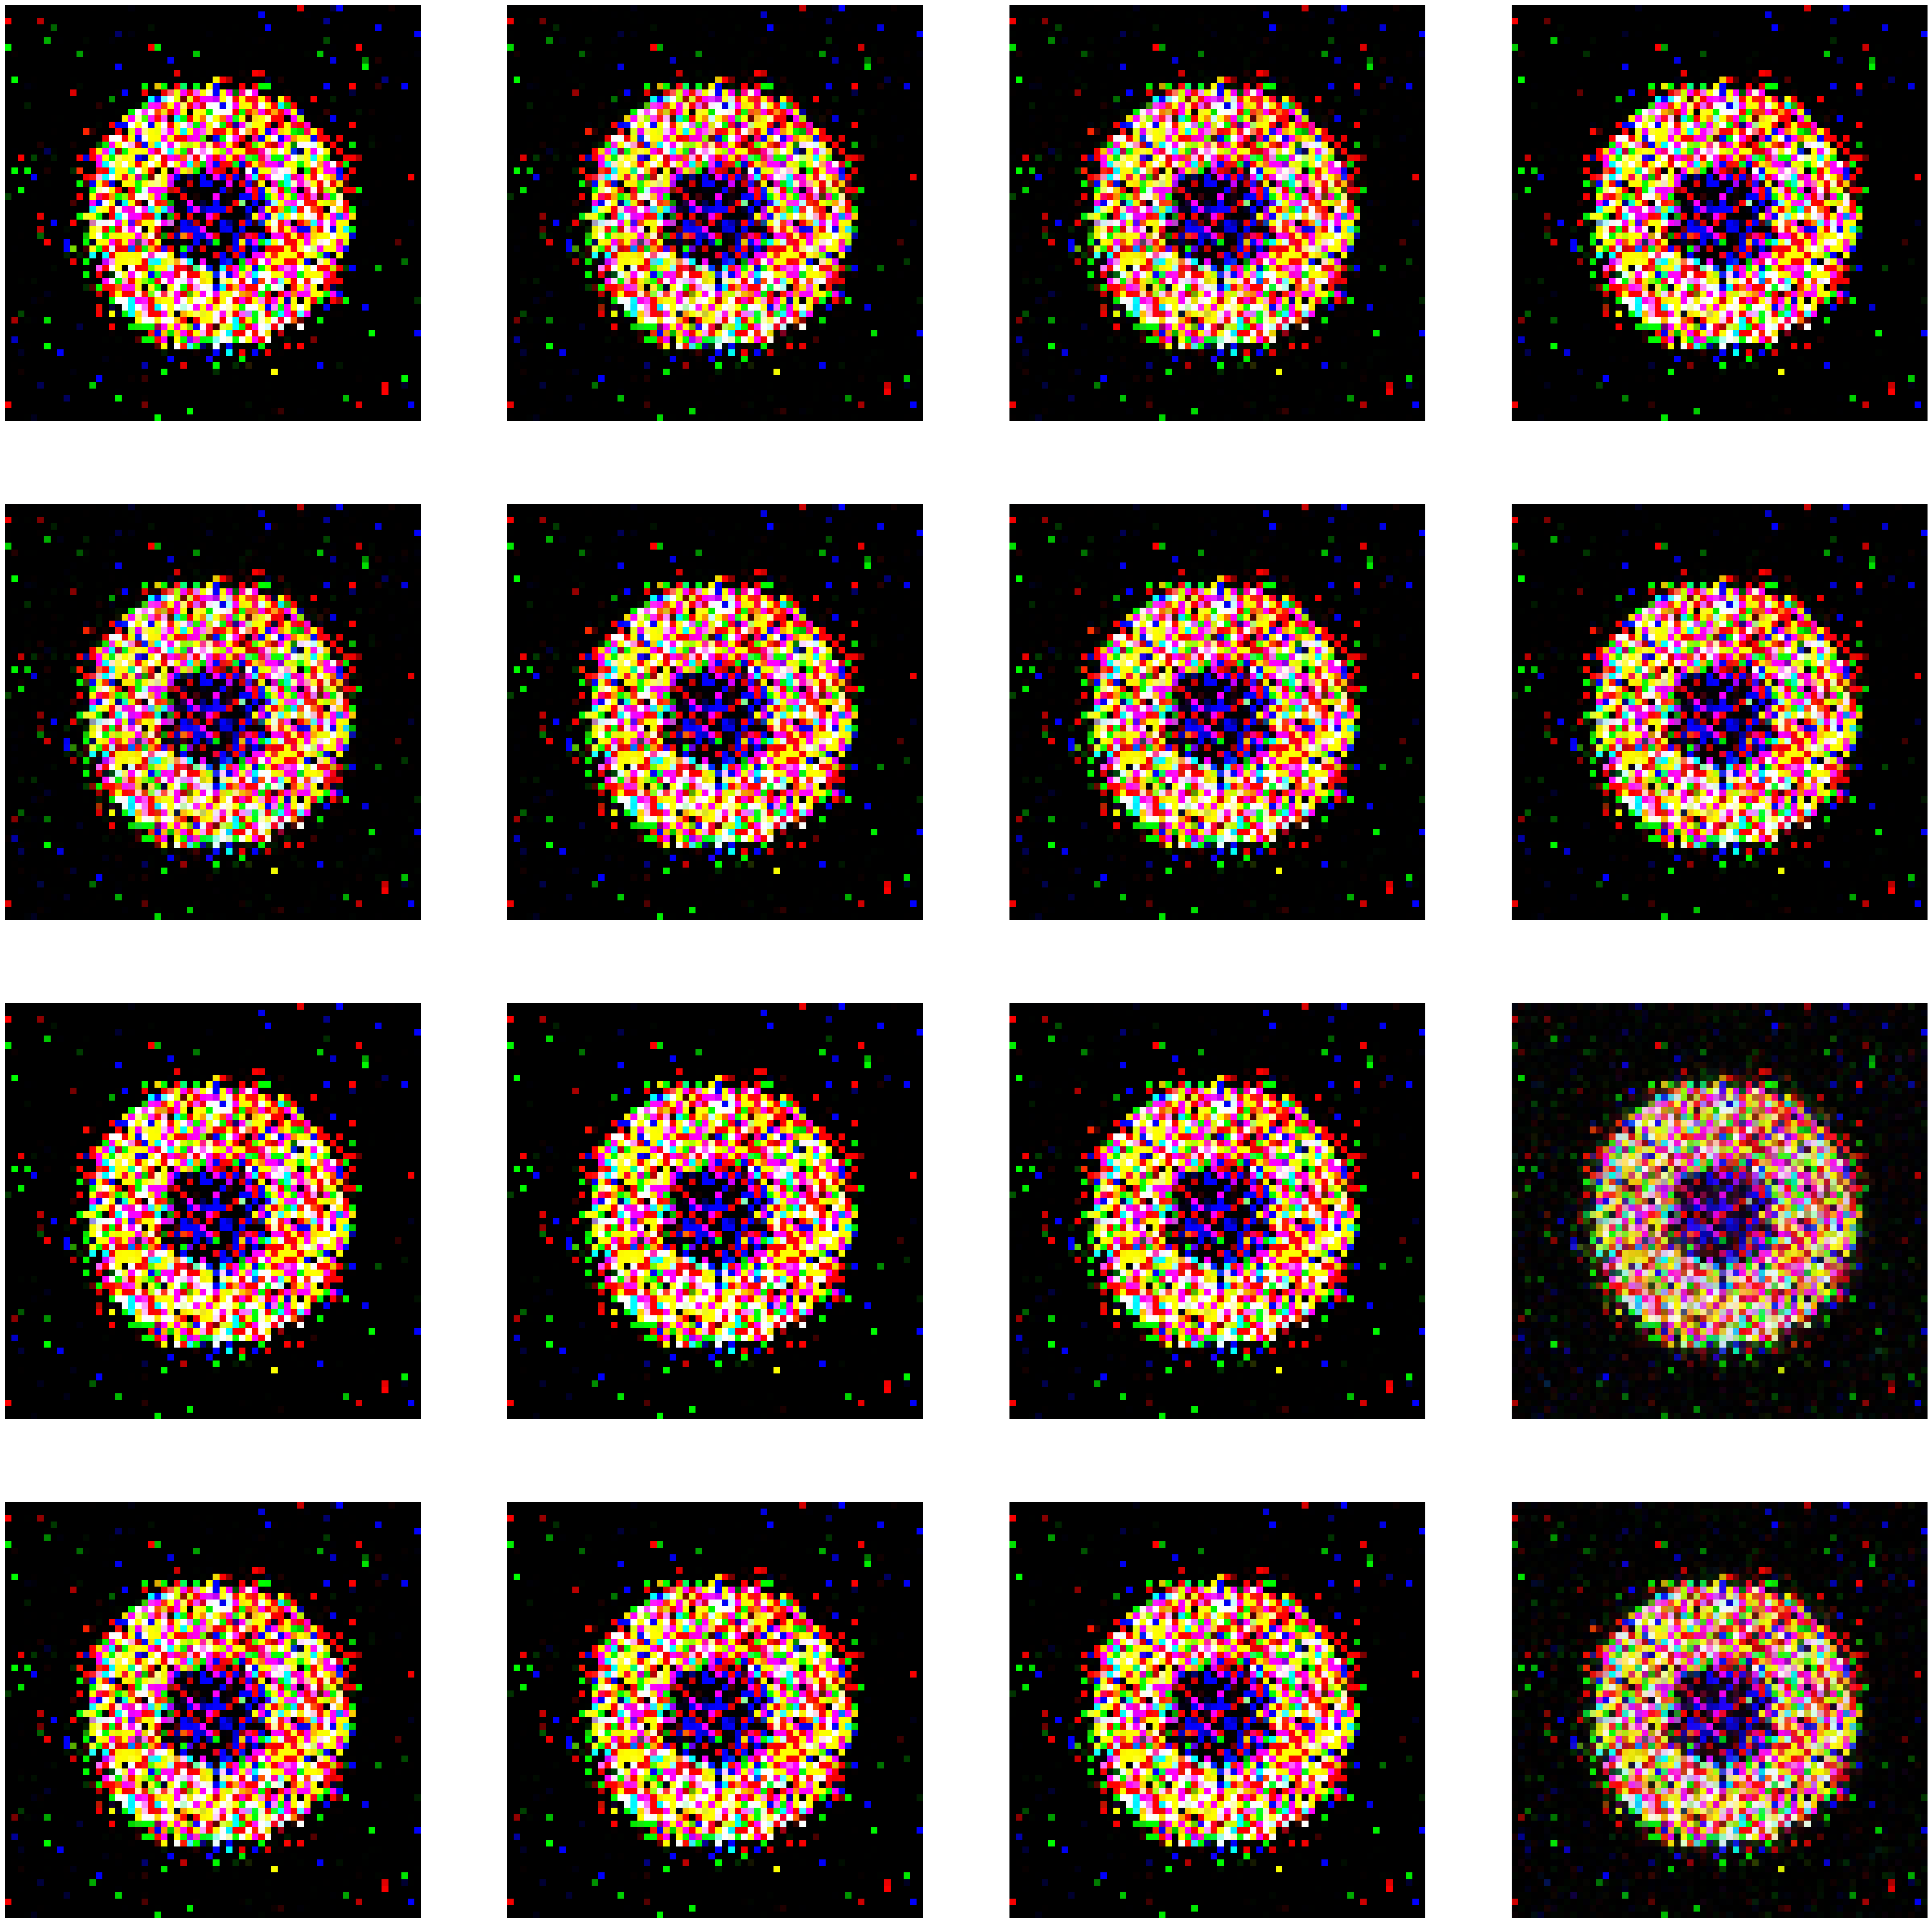

In [65]:
generated = generated.numpy()

generated = generated.reshape(
    -1,64,64,3
)

generated = (generated + 1)/2

plt.figure(figsize=(50,50))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(generated[i])

    plt.axis('off')

plt.show()